<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/DAX/filtro_selecionado_dax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Filtros

#### Mostrando Filtros selecionados, filtros ativos, mensagem de quando o filtro foi selecionado e etc...

#### 1) Perido selecionado *(normalmente usando o d_calendario[Date)*

In [ ]:
PeriodoSelecionado =
VAR MinData = MIN(d_Calendario[Date])
VAR MaxData = MAX(d_Calendario[Date])
RETURN
"Período Selecionado: "
    & FORMAT(MinData,"dd/MM/yyyy")
    & " até "
    & FORMAT(MaxData,"dd/MM/yyyy")

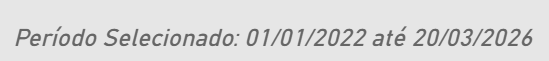

#### 2) Mostrar a quantidade de segmentos selecionaodos *(esse menos importante, mas válido saber)*.

In [ ]:
QtdFiltrosAtivos =
VAR DataFiltro = ISFILTERED(d_Calendario[Date])
VAR StatusFiltro = ISFILTERED(d_Status[Status])
VAR ClienteFiltro = ISFILTERED(d_Cliente[APELIDO CLIENTE])
RETURN
DataFiltro + StatusFiltro + ClienteFiltro

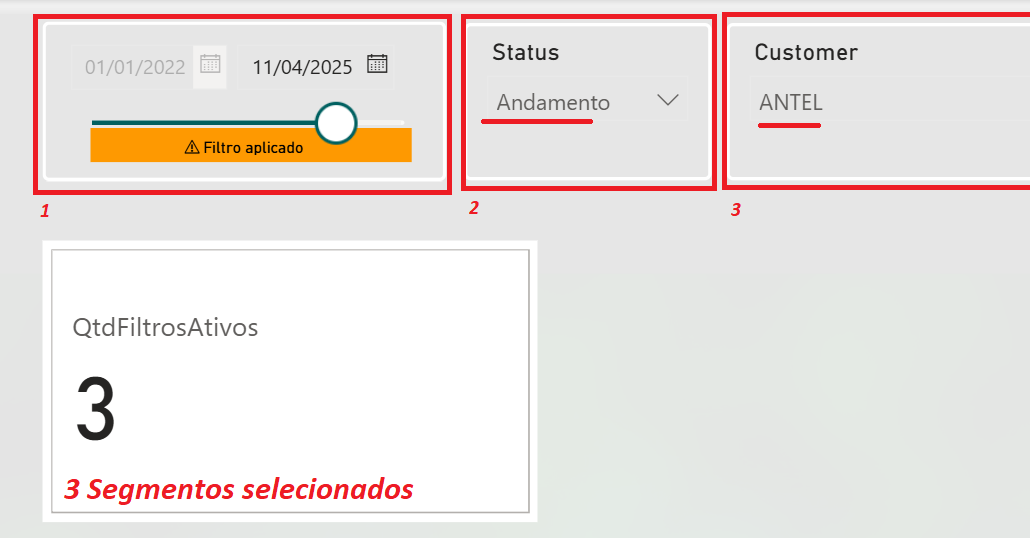

#### 3) Lista de Itens Selecionados

In [ ]:
Empresas Selecionada =
VAR Lista =
CONCATENATEX(
    VALUES(d_Cliente[Company]),
    d_Cliente[Company],
    ", "
)
RETURN
"Empresas: " & Lista

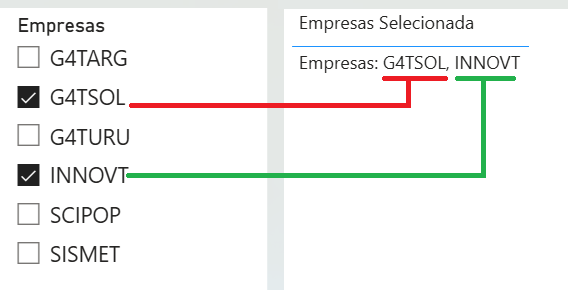

#### 4) Mostrar se o filtro está aplicado (Estilo Checkbox)

In [ ]:
FiltroAtivo =
IF( ISFILTERED(d_Calendario_Filtro[Date]), "⚠ Filtro aplicado", "Dados completos" )

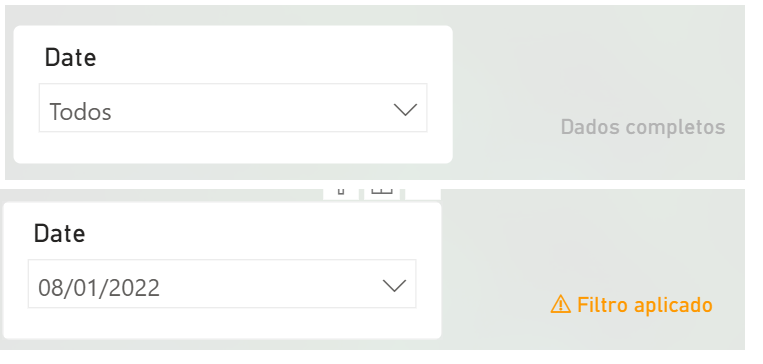

#### 5) Mostrar se o filtro está aplicado (Estilo Slice)

In [ ]:
FiltroAtivo =

VAR MinSelecionado = MIN(d_Calendario[Date])
VAR MaxSelecionado = MAX(d_Calendario[Date])
VAR MinTotal = CALCULATE(MIN(d_Calendario[Date]), ALL(d_Calendario))
VAR MaxTotal = CALCULATE(MAX(d_Calendario[Date]), ALL(d_Calendario))
RETURN
IF(
    MinSelecionado > MinTotal || MaxSelecionado < MaxTotal,
    "⚠ Filtro aplicado",
    "Dados completos"
)

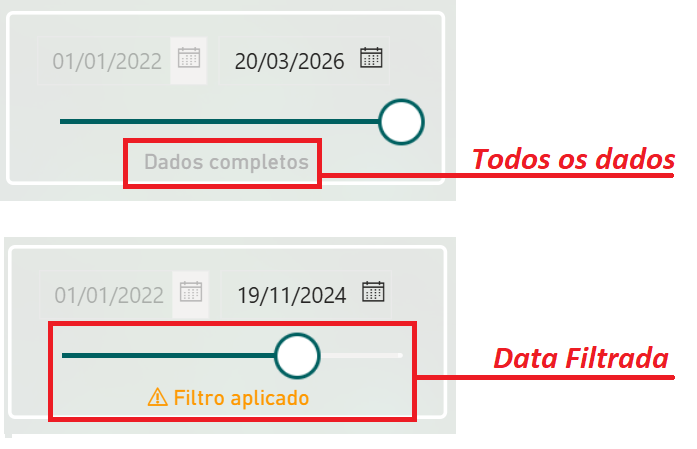

#### 6) Mostrar o Resumo de Filtros
Aqui o exemplo é com 2 segmentos, mas da para acrescentar mais segmento de dados, apenas inserindo variáveis.


In [ ]:
ResumoFiltros =
VAR Empresa =
CONCATENATEX(VALUES(d_Cliente[Company]), d_Cliente[Company], ", ")

VAR Agrupador =
CONCATENATEX(VALUES(d_AgrupadorEbitida[Agrupador Ebitda (para usar no filtro)]), d_AgrupadorEbitida[Agrupador Ebitda (para usar no filtro)], ", ")

RETURN
"Empresa: " & Empresa &
" | Agrupador: " & Agrupador

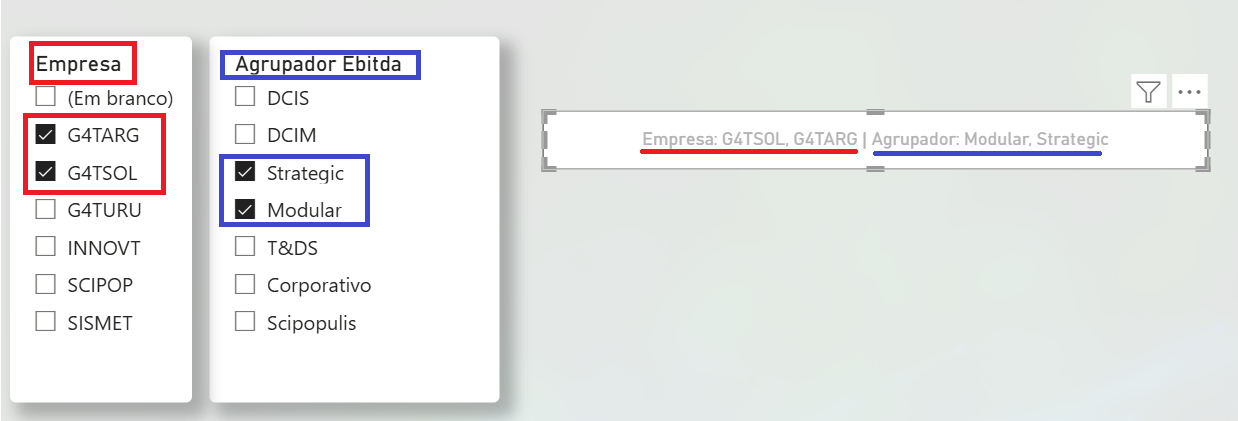